In [1]:
import matplotlib.pyplot as plt
from OptimalBattery.global_config import repo_dir,save_dir
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as mpl
mpl.rcParams["pdf.fonttype"] = 42
from scipy.stats import pearsonr
from scipy.stats import sem
from scipy.stats import ttest_rel
import os
from statsmodels.stats.anova import AnovaRM


In [2]:
metrics = ['random','variance','inverse_trace_mc']

custom_palette = {
    'random': 'black',
    'variance': '#0072B2',
    'variance_mc': '#009E73',
    'log_det_mc': '#E69F00',
    'inverse_trace_mc': '#D55E00'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

# parcellation simulation

In [3]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'parcellation_sim.tsv')
D = pd.read_csv(saved_file, sep='\t')
D = D[D['metric'].isin(metrics)]

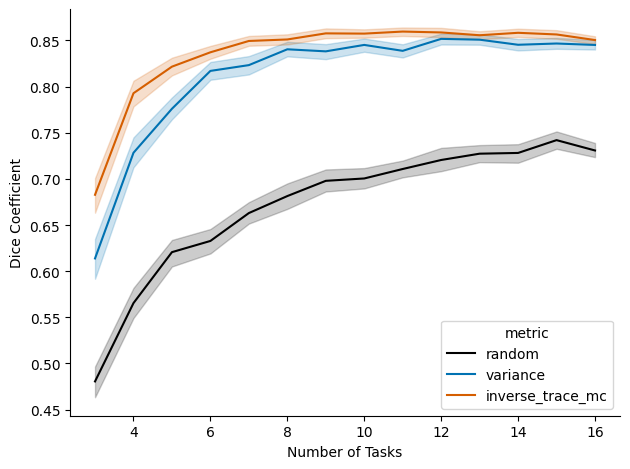

In [5]:
sns.lineplot(
    data=D,
    x="n_task",
    y="accuracy",
    hue="metric",
    palette=custom_palette,

)

plt.xlabel("Number of Tasks")
plt.ylabel("Dice Coefficient")
plt.tight_layout()
sns.despine()
# plt.savefig(f"{save_dir}/battery_criteria/sim_parcellate.pdf", format="pdf", bbox_inches="tight")
plt.show()

# connectivity simulation

In [6]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'connectivity_sim.tsv')
D = pd.read_csv(saved_file, sep='\t')
# defube metrics to plot
D = D[D['metric'].isin(metrics)]

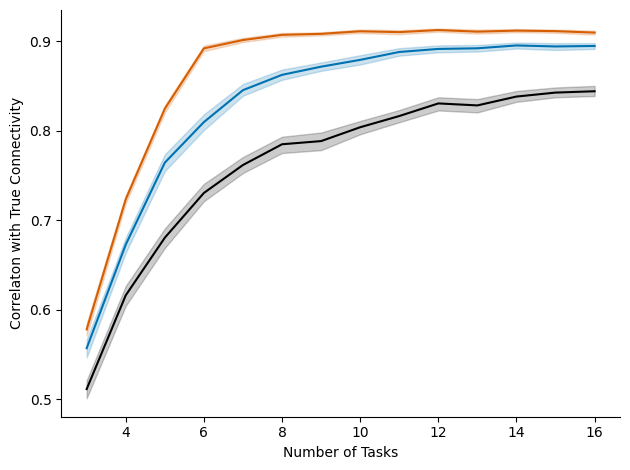

In [7]:
sns.lineplot(
    data=D,
    x="n_task",
    y="correlation",
    hue="metric",
    palette=custom_palette,
)

plt.xlabel("Number of Tasks")
plt.ylabel("Correlaton with True Connectivity")
plt.legend([],[], frameon=False)
plt.tight_layout()
sns.despine()
# plt.savefig(f"{save_dir}/battery_criteria/sim_connectivity.pdf", format="pdf", bbox_inches="tight")
plt.show()

# parcellation real (cortex)

In [22]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'parcellation_real_cortex.tsv')
D = pd.read_csv(saved_file, sep='\t')
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1
D= D[D['roi']== 'All Parcels']

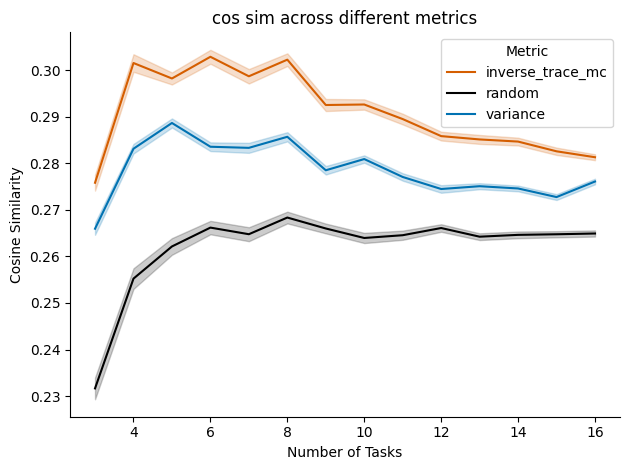

In [23]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_cos_sim_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_cos_sim_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_cos_sim_per_subject"] - subject_mean + task_mean

sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    errorbar='se',
    palette=custom_palette,
)


plt.xlabel("Number of Tasks")
plt.ylabel("Cosine Similarity")
plt.title(f"cos sim across different metrics")
sns.despine()
plt.legend(title="Metric")
plt.tight_layout()
# plt.savefig(f"{save_dir}/battery_criteria/real_cortical_all.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [10]:
avg_df = D.groupby(['sub', 'metric'], as_index=False)['avg_cos_sim_per_subject'].mean()
it = avg_df[avg_df.metric == 'inverse_trace_mc']['avg_cos_sim_per_subject'].values
v = avg_df[avg_df.metric == 'variance']['avg_cos_sim_per_subject'].values
rand = avg_df[avg_df.metric == 'random']['avg_cos_sim_per_subject'].values


t, p = ttest_rel(v, rand)
print(t,p)

t, p = ttest_rel(it, rand)
print(t,p)

10.544947383208699 2.7830610159325377e-10
13.861876040453824 1.1807486998565476e-12


In [11]:
t, p = ttest_rel(it, v)
print(t,p)

9.360118675698484 2.6222427368702294e-09


In [12]:
# Get inverse_trace_mc data
dd_df = (
    D[D.metric == 'inverse_trace_mc'][['sub', 'n_task', 'avg_cos_sim_per_subject']]
    .copy()
)
dd_df['selection'] = 'inverse_trace_mc'

# Get random data
rand_df = D[D.metric == 'random'][['sub', 'n_task', 'avg_cos_sim_per_subject']].copy()
rand_df['selection'] = 'random'

# Combine for ANOVA
anova_df = pd.concat([dd_df, rand_df], ignore_index=True)

aov = AnovaRM(
    anova_df,
    depvar='avg_cos_sim_per_subject',
    subject='sub',
    within=['selection', 'n_task']
)

res = aov.fit()
print(res)

                      Anova
                 F Value   Num DF  Den DF  Pr > F
-------------------------------------------------
selection        192.1516  1.0000  23.0000 0.0000
n_task            52.0103 13.0000 299.0000 0.0000
selection:n_task  53.1995 13.0000 299.0000 0.0000



# parcellation real (PFC)

In [13]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'parcellation_real_cortex.tsv')
D = pd.read_csv(saved_file, sep='\t')
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1
D= D[D['roi']== 'PFC']

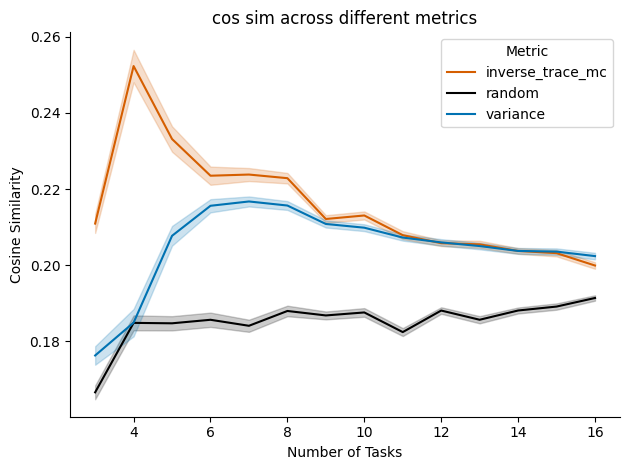

In [15]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_cos_sim_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_cos_sim_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_cos_sim_per_subject"] - subject_mean + task_mean

sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    errorbar='se',
    palette=custom_palette,
)


plt.xlabel("Number of Tasks")
plt.ylabel("Cosine Similarity")
plt.title(f"cos sim across different metrics")
sns.despine()
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(f"{save_dir}/battery_criteria/real_PFC.pdf", format="pdf", bbox_inches="tight")
plt.show()

# parcellation real (cerebellum)

In [16]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'parcellation_real_cerebellum.tsv')
D = pd.read_csv(saved_file, sep='\t')
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1
D = D[D['roi']=='all']


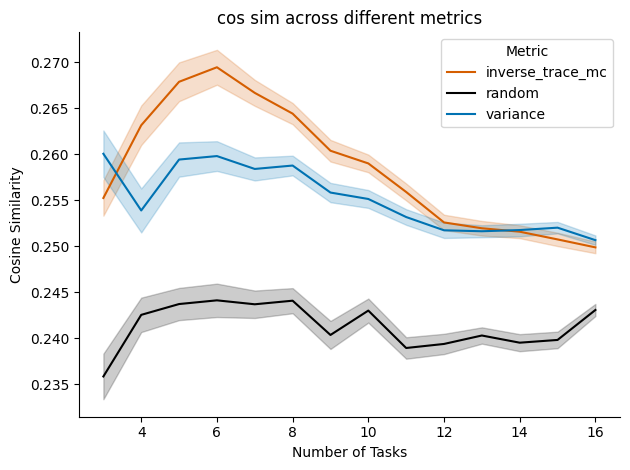

In [17]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_cos_sim_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_cos_sim_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_cos_sim_per_subject"] - subject_mean + task_mean

sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    errorbar='se',
    palette=custom_palette,
)


plt.xlabel("Number of Tasks")
plt.ylabel("Cosine Similarity")
plt.title(f"cos sim across different metrics")
sns.despine()
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(f"{save_dir}/battery_criteria/real_cerebellum_all.pdf", format="pdf", bbox_inches="tight")
plt.show()

# connectivity real

In [18]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'real_connectivity_org.tsv')
D = pd.read_csv(saved_file, sep='\t')
# defube metrics to plot
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1

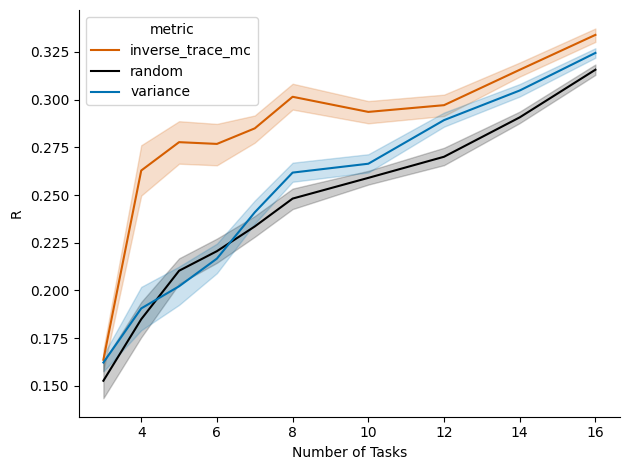

In [19]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_correlation_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_correlation_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_correlation_per_subject"] - subject_mean + task_mean

sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    palette=custom_palette,
)

plt.xlabel("Number of Tasks")
plt.ylabel("R")
# remove legend 
plt.tight_layout()
sns.despine()
plt.savefig(f"{save_dir}/battery_criteria/real_connectivity.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [88]:
avg_df = D.groupby(['sub', 'metric'], as_index=False)['avg_correlation_per_subject'].mean()
it = avg_df[avg_df.metric == 'inverse_trace_mc']['avg_correlation_per_subject'].values
v = avg_df[avg_df.metric == 'variance']['avg_correlation_per_subject'].values
rand = avg_df[avg_df.metric == 'random']['avg_correlation_per_subject'].values


t, p = ttest_rel(v, rand)
print(t,p)
t, p = ttest_rel(it, rand)
print(t,p)


2.076607855110563 0.049196127019814045
8.13651397669789 3.204554825340062e-08


In [89]:
t, p = ttest_rel(it, v)
print(t,p)


6.942192706261965 4.4657509005683877e-07


In [91]:
# Get inverse_trace_mc data
dd_df = (
    D[D.metric == 'inverse_trace_mc'][['sub', 'n_task', 'avg_correlation_per_subject']]
    .copy()
)
dd_df['selection'] = 'inverse_trace_mc'

# Get random data
rand_df = D[D.metric == 'random'][['sub', 'n_task', 'avg_correlation_per_subject']].copy()
rand_df['selection'] = 'random'

# Combine for ANOVA
anova_df = pd.concat([dd_df, rand_df], ignore_index=True)

aov = AnovaRM(
    anova_df,
    depvar='avg_correlation_per_subject',
    subject='sub',
    within=['selection', 'n_task']
)

res = aov.fit()
print(res)

                     Anova
                 F Value  Num DF  Den DF  Pr > F
------------------------------------------------
selection         66.2029 1.0000  23.0000 0.0000
n_task           128.9473 9.0000 207.0000 0.0000
selection:n_task  24.8181 9.0000 207.0000 0.0000

